In [1]:
import gzip
from pathlib import Path

import gffutils
from matplotlib import pyplot as plt
from matplotlib_venn import venn2
import numpy as np
import polars as pl
from safetensors.torch import load_file
from scipy.stats import entropy, mannwhitneyu, wilcoxon
import seaborn as sns
from statannotations.Annotator import Annotator

import torch

# Strand comparison

This notebook compares the results from the forward and reverse strands using IC difference, KL divergence and top decile intersection.

# Data loading

In [2]:
basepath = Path("/no_backup/rg/itrujnara/infer_chromosome/tensors")

In [3]:
size = 2**20
stride = size - 8192
chr_size = 46709983

In [4]:
chunks = []

for start in range(0,chr_size,stride):
    end = start + size
    filename = f"ch38_chr21_{start}_{end}_probs.safetensors"
    try:
        chunk_probs = load_file(basepath / filename)["probs"]
        chunks.append(chunk_probs)
    except FileNotFoundError:
        print(filename + " not found")

ch38_chr21_0_1048576_probs.safetensors not found
ch38_chr21_1040384_2088960_probs.safetensors not found
ch38_chr21_2080768_3129344_probs.safetensors not found
ch38_chr21_3121152_4169728_probs.safetensors not found


In [5]:
chunks_rc = []

for start in range(0,chr_size,stride):
    end = start + size
    filename = f"ch38_chr21_rc_{start}_{end}_probs.safetensors"
    try:
        chunk_probs = load_file(basepath / filename)["probs"]
        chunks_rc.append(chunk_probs)
    except FileNotFoundError:
        print(filename + " not found")

ch38_chr21_rc_0_1048576_probs.safetensors not found
ch38_chr21_rc_1040384_2088960_probs.safetensors not found
ch38_chr21_rc_2080768_3129344_probs.safetensors not found
ch38_chr21_rc_3121152_4169728_probs.safetensors not found


# Strand comparison

## Tensor computation

In [6]:
probs_fwd = torch.cat(chunks)[:-8192]

In [7]:
probs_fwd.shape

torch.Size([42532063, 4])

In [8]:
probs_rc = torch.cat(chunks_rc)[8192:]

In [9]:
probs_rc.shape

torch.Size([42532063, 4])

In [10]:
ic_fwd = 2 - entropy(probs_fwd, axis=1, base=2)

In [11]:
ic_rc = 2 - entropy(probs_rc, axis=1, base=2)

## IC distance

In [12]:
diff_real = ic_fwd - ic_rc

In [13]:
(diff_real ** 2).sum() ** 0.5

np.float32(2563.6008)

Text(0, 0.5, 'Count')

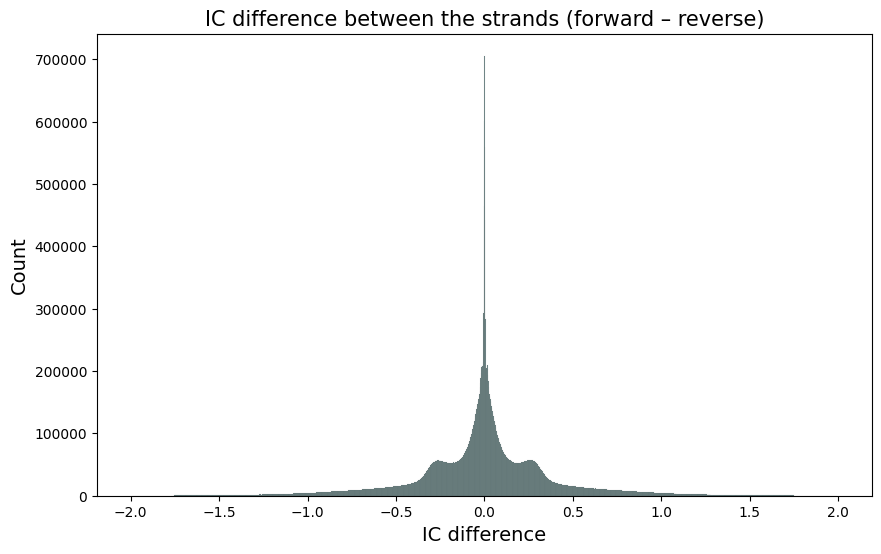

In [14]:
fig, ax = plt.subplots(figsize=(10,6))

sns.histplot(diff_real, ax=ax, color="#466365")
ax.set_title("IC difference between the strands (forward – reverse)", fontsize=15)
ax.set_xlabel("IC difference", fontsize=14)
ax.set_ylabel("Count", fontsize=14)

In [15]:
diff_real.mean()

np.float32(0.0006924849)

In [16]:
diff_real.std()

np.float32(0.39308986)

In [17]:
(diff_real > 0).mean()

np.float64(0.50105331123957)

In [18]:
(diff_real == 0.).mean()

np.float64(6.113035241201444e-07)

In [19]:
(diff_real < -0.5).mean()

np.float64(0.0785705127917261)

In [20]:
(diff_real > 0.5).mean()

np.float64(0.07894883913813444)

In [21]:
rng = np.random.default_rng(42)

ic_random = rng.permutation(ic_fwd)

In [22]:
((ic_fwd - ic_random)**2).sum()**0.5

np.float32(5722.4307)

In [23]:
dist_real_1 = entropy(probs_rc, probs_fwd, axis=1, base=2)

In [24]:
dist_real_2 = entropy(probs_fwd, probs_rc, axis=1, base=2)

In [25]:
dist_real_1.mean()

np.float32(1.4727612)

In [26]:
dist_real_1.std()

np.float32(2.2552545)

In [27]:
dist_real_2.mean()

np.float32(1.4686875)

In [28]:
dist_real_2.std()

np.float32(2.2442646)

In [29]:
torch.random.manual_seed(42)

idx = torch.randperm(probs_fwd.shape[0])

probs_random = probs_fwd[idx,:]

In [30]:
dist_random_1 = entropy(probs_random, probs_fwd, axis=1, base=2)

In [31]:
dist_random_1.mean()

np.float32(1.4178997)

In [32]:
dist_random_1.std()

np.float32(1.6190768)

In [33]:
dist_random_2 = entropy(probs_fwd, probs_random, axis=1, base=2)

In [34]:
dist_random_2.mean()

np.float32(1.4178963)

In [35]:
dist_random_2.std()

np.float32(1.6189867)

In [36]:
entropy([0.4,0.1,0.1,0.4], [0.3,0.2,0.2,0.3], base=2)

np.float64(0.1320299994230752)

## Top 10% intersection

In [37]:
quantile_fwd = np.quantile(ic_fwd, 0.9)
quantile_fwd

np.float32(1.6412253)

In [38]:
quantile_rc = np.quantile(ic_rc, 0.9)
quantile_rc

np.float32(1.6408143)

In [39]:
idx_fwd = np.argwhere(ic_fwd > quantile_fwd).flatten()
idx_fwd

array([  840291,   840294,   840298, ..., 42530252, 42530253, 42530254])

In [40]:
idx_rc = np.argwhere(ic_rc > quantile_rc).flatten()
idx_rc

array([  840274,   840275,   840291, ..., 42530238, 42530239, 42530241])

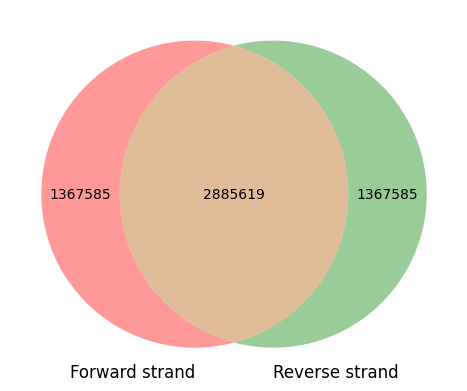

In [41]:
v = venn2((set(idx_fwd), set(idx_rc)), set_labels=("Forward strand", "Reverse strand"))

## Merging the strands

In [42]:
ic_mean = (ic_fwd + ic_rc) / 2

In [43]:
ic_mean

array([0.02647281, 0.02698147, 0.02795202, ..., 0.01942354, 0.01832968,
       0.0181936 ], dtype=float32)

In [44]:
ic_max = np.maximum(ic_fwd, ic_rc)

In [45]:
ic_max

array([0.02855027, 0.02996826, 0.02949953, ..., 0.0264045 , 0.02399468,
       0.02439535], dtype=float32)

In [46]:
db = gffutils.FeatureDB("/users/cn/itrujnara/genomes-project/infer_chromosome/compare_gff/gencode.v48.chr21.db")

In [47]:
def get_feature_ics(gff_db, ics, feature_type, gene_type=None, exclude_type=None, offset=4169728):
    """Extract and concatenate the positions of the IC track spanned by a given GFF feature."""
    feature_ranges = []

    for feature in gff_db.features_of_type(feature_type, order_by=("start")):
        if gene_type is not None and gene_type not in feature["gene_type"]:
            continue
        if exclude_type is not None and exclude_type in feature["gene_type"]:
            continue
        feature_ranges.append((feature.start - offset, feature.end - offset))

    feature_ics = []

    for feature in feature_ranges:
        feature_ic = ics[feature[0]:feature[1]]
        feature_ics.append(feature_ic)

    return np.concatenate(feature_ics)

In [48]:
def get_intron_ics(gff_db, ics, gene_type=None, offset=4169728):
    intron_ranges = []
    
    for intron in gff_db.create_introns():
        if gene_type is not None and gene_type not in intron["gene_type"]:
            continue
        intron_ranges.append((intron.start - offset, intron.end - offset))
    
    intron_ics = []
    
    for intron in intron_ranges:
        intron_ic = ics[intron[0]:intron[1]]
        intron_ics.append(intron_ic)
    
    intron_ic_arr = np.concatenate(intron_ics)

    return intron_ic_arr

In [49]:
def array_to_df(arr, group_name):
    return pl.DataFrame({"value": arr, "label": [group_name] * arr.shape[0]})

In [50]:
gene_ics_mean = get_feature_ics(db, ic_mean, "gene")
pc_gene_ics_mean = get_feature_ics(db, ic_mean, "gene", "protein_coding")

In [51]:
df_all_mean = array_to_df(ic_mean, "All positions")
df_genes_mean = array_to_df(gene_ics_mean, "All genes")
df_pc_genes_mean = array_to_df(pc_gene_ics_mean, "Protein-coding genes")
df_mean = df_all_mean.vstack(df_genes_mean).vstack(df_pc_genes_mean)

Text(0, 0.5, 'Information content')

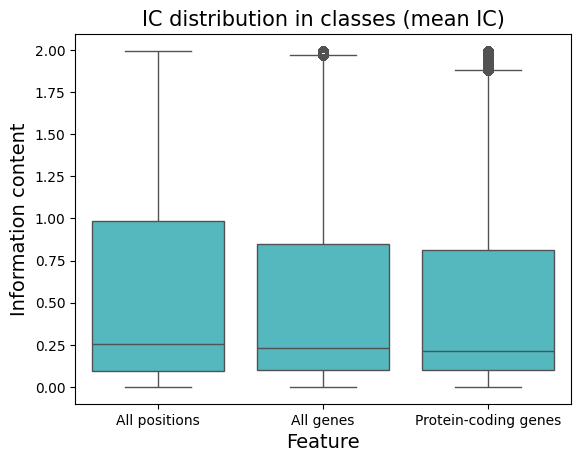

In [52]:
order = ["All positions", "All genes", "Protein-coding genes"]

plot_params = {
    "data": df_mean,
    "x": "label",
    "y": "value"
}

ax = sns.boxplot(**plot_params, color="#43C7CF")

ax.set_title("IC distribution in classes (mean IC)", fontsize=15)
ax.set_xlabel("Feature", fontsize=14)
ax.set_ylabel("Information content", fontsize=14)

In [53]:
gene_ics_max = get_feature_ics(db, ic_max, "gene")
pc_gene_ics_max = get_feature_ics(db, ic_max, "gene", "protein_coding")

In [54]:
df_all_max = array_to_df(ic_max, "All positions")
df_genes_max = array_to_df(gene_ics_max, "All genes")
df_pc_genes_max = array_to_df(pc_gene_ics_max, "Protein-coding genes")
df_max = df_all_max.vstack(df_genes_max).vstack(df_pc_genes_max)

Text(0, 0.5, 'Information content')

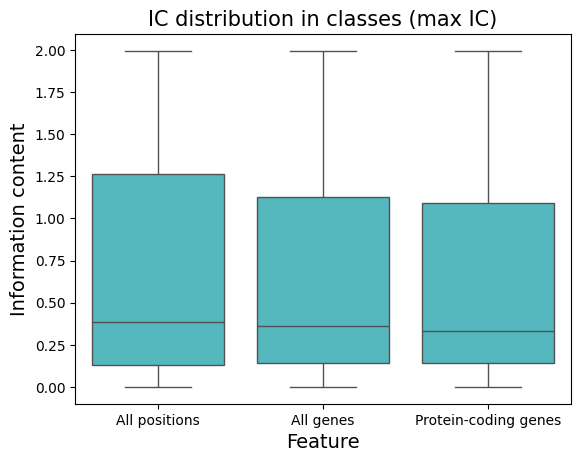

In [55]:
order = ["All positions", "All genes", "Protein-coding genes"]

plot_params = {
    "data": df_max,
    "x": "label",
    "y": "value"
}

ax = sns.boxplot(**plot_params, color="#43C7CF")

ax.set_title("IC distribution in classes (max IC)", fontsize=15)
ax.set_xlabel("Feature", fontsize=14)
ax.set_ylabel("Information content", fontsize=14)

In [56]:
pc_exon_ics_mean = get_feature_ics(db, ic_mean, "exon", "protein_coding")
cds_ics_mean = get_feature_ics(db, ic_mean, "CDS", "protein_coding")
pc_intron_ics_mean = get_intron_ics(db, ic_mean, "protein_coding")

In [57]:
df_pc_exon_mean = array_to_df(pc_exon_ics_mean, "Protein-coding gene\nexons")
df_cds_mean = array_to_df(cds_ics_mean, "Protein-coding CDS")
df_pc_intron_mean = array_to_df(pc_intron_ics_mean, "Protein-coding gene\nintrons")
df_pc_mean = df_pc_intron_mean.vstack(df_pc_exon_mean).vstack(df_cds_mean)

Text(0, 0.5, 'Information content')

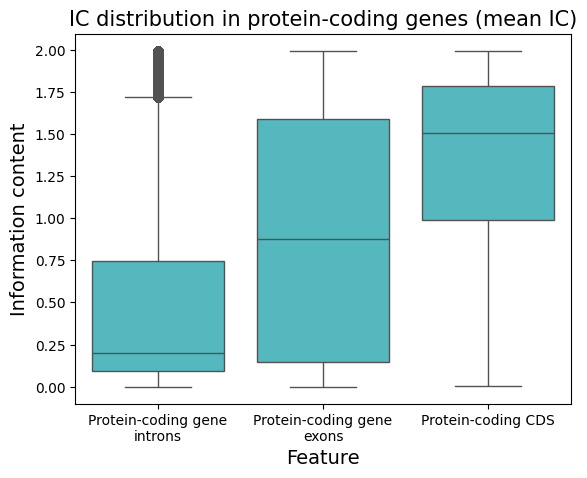

In [77]:
ax = sns.boxplot(data=df_pc_mean, x="label", y="value", color="#43C7CF")

ax.set_title("IC distribution in protein-coding genes (mean IC)", fontsize=15)
ax.set_xlabel("Feature", fontsize=14)
ax.set_ylabel("Information content", fontsize=14)

In [59]:
pc_exon_ics_max = get_feature_ics(db, ic_max, "exon", "protein_coding")
cds_ics_max = get_feature_ics(db, ic_max, "CDS", "protein_coding")
pc_intron_ics_max = get_intron_ics(db, ic_max, "protein_coding")

In [60]:
df_pc_exon_max = array_to_df(pc_exon_ics_max, "Protein-coding gene\nexons")
df_cds_max = array_to_df(cds_ics_max, "Protein-coding CDS")
df_pc_intron_max = array_to_df(pc_intron_ics_max, "Protein-coding gene\nintrons")
df_pc_max = df_pc_intron_max.vstack(df_pc_exon_max).vstack(df_cds_max)

Text(0, 0.5, 'Information content')

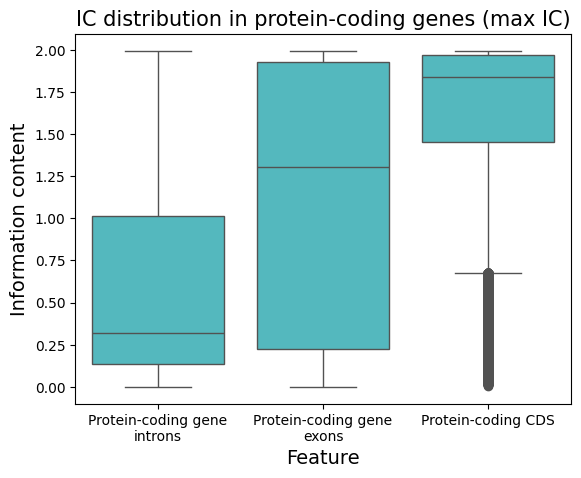

In [61]:
ax = sns.boxplot(data=df_pc_max, x="label", y="value", color="#43C7CF")

ax.set_title("IC distribution in protein-coding genes (max IC)", fontsize=15)
ax.set_xlabel("Feature", fontsize=14)
ax.set_ylabel("Information content", fontsize=14)

## phastCons

In [62]:
cons_values = []

with gzip.open("/users/cn/itrujnara/genomes-project/infer_chromosome/conservation/chr21.phastCons470way.wigFix.gz") as f:
    for line in f:
        if not line.startswith(b"fixed"):
            cons_values.append(float(line))

cons_values = np.array(cons_values)

In [63]:
pc_start = 5010001 - 4169728
pc_end = pc_start + cons_values.shape[0]

In [69]:
ic_mean_trimmed = ic_mean[pc_start:pc_end]

In [78]:
ic_mean_quantile = np.quantile(ic_mean_trimmed, 0.9)
ic_mean_idx = np.argwhere(ic_mean_trimmed >= ic_mean_quantile).flatten()

In [79]:
ic_max_trimmed = ic_max[pc_start:pc_end]

In [80]:
ic_max_quantile = np.quantile(ic_max_trimmed, 0.9)
ic_max_idx = np.argwhere(ic_max_trimmed >= ic_max_quantile).flatten()

In [81]:
cons_quantile = np.quantile(cons_values, 0.9)
cons_idx = np.argwhere(cons_values >= cons_quantile).flatten()

In [82]:
np.intersect1d(ic_mean_idx, cons_idx).shape[0] / ic_idx.shape[0]

0.13007605974221476

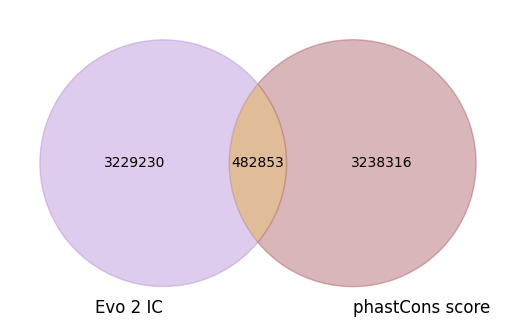

In [83]:
v = venn2((set(ic_mean_idx), set(cons_idx)), set_labels=("Evo 2 IC", "phastCons score"))
v.get_patch_by_id("10").set_color("#AB81CD")
v.get_patch_by_id("01").set_color("#9F4A54")

In [84]:
np.intersect1d(ic_max_idx, cons_idx).shape[0] / ic_idx.shape[0]

0.13171179946994704

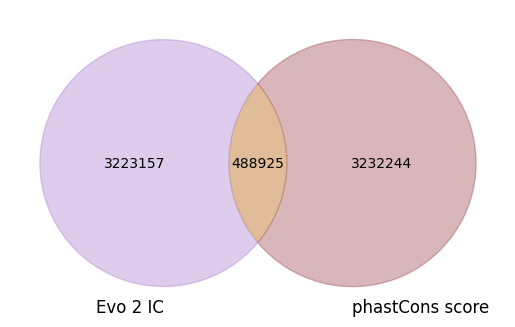

In [85]:
v = venn2((set(ic_max_idx), set(cons_idx)), set_labels=("Evo 2 IC", "phastCons score"))
v.get_patch_by_id("10").set_color("#AB81CD")
v.get_patch_by_id("01").set_color("#9F4A54")